In [1]:
import pandas as pd
import numpy as np
from datasets import load_dataset
from sklearn.model_selection import train_test_split

# Для воспроизводимости результатов фиксируем случайный генератор
RANDOM_STATE = 42

In [2]:
# Загрузка датасета
dataset = load_dataset("dair-ai/emotion")

# Посмотрим, какие сплиты (разбиения) доступны в датасете
print("Доступные сплиты:", dataset.keys())

Доступные сплиты: dict_keys(['train', 'validation', 'test'])


In [3]:
# Sanity Check (Проверка данных)

# 1. Размер датасета
print("\n--- Размер датасета ---")
for split in dataset.keys():
    print(f"{split}: {len(dataset[split])} примеров")

# 2. Названия классов
# В датасете emotion метки закодированы числами. Нам нужно получить их названия.
# Обычно они хранятся в feature information
labels = dataset['train'].features['label'].names
print("\n--- Названия классов ---")
print(f"Классы ({len(labels)} шт.): {labels}")

# 3. Примеры текстов и меток
print("\n--- Примеры данных (первые 5 из train) ---")
train_df = dataset['train'].to_pandas()
print(train_df[['text', 'label']].head())

# Добавим колонку с именем класса для наглядности
train_df['label_name'] = train_df['label'].apply(lambda x: labels[x])
print("\n--- Примеры с именами классов ---")
print(train_df[['text', 'label_name']].head())


--- Размер датасета ---
train: 16000 примеров
validation: 2000 примеров
test: 2000 примеров

--- Названия классов ---
Классы (6 шт.): ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

--- Примеры данных (первые 5 из train) ---
                                                text  label
0                            i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned...      0
2   im grabbing a minute to post i feel greedy wrong      3
3  i am ever feeling nostalgic about the fireplac...      2
4                               i am feeling grouchy      3

--- Примеры с именами классов ---
                                                text label_name
0                            i didnt feel humiliated    sadness
1  i can go from feeling so hopeless to so damned...    sadness
2   im grabbing a minute to post i feel greedy wrong      anger
3  i am ever feeling nostalgic about the fireplac...       love
4                               i am feeling grouc

In [4]:
# Разбиение на Train / Validation / Test
# Данный код проверяет есть ли validation, а если нет, то при обходимости создаст его.

# Проверяем, есть ли официальный validation
if 'validation' in dataset:
    print("Используем официальный сплит validation.")
    train_dataset = dataset['train']
    val_dataset = dataset['validation']
    test_dataset = dataset['test']
else:
    print("Официальный validation отсутствует. Создаем его из train.")
    # Делим train на train и validation (например, 80% / 20%)
    train_test_split_data = train_test_split(
        dataset['train'], 
        test_size=0.2, 
        random_state=RANDOM_STATE,
        stratify=dataset['train']['label'] # Сохраняем распределение классов
    )
    train_dataset = train_test_split_data[0]
    val_dataset = train_test_split_data[1]
    test_dataset = dataset['test'] # Если есть test, иначе тоже пришлось бы делить

# Выводим итоговые размеры
print("\n--- Итоговое разбиение ---")
print(f"Train: {len(train_dataset)}")
print(f"Validation: {len(val_dataset)}")
print(f"Test: {len(test_dataset)}")

Используем официальный сплит validation.

--- Итоговое разбиение ---
Train: 16000
Validation: 2000
Test: 2000


In [5]:
#  Сохранение артефактов

# Сохраняем данные в папку artifacts для отчетности и дальнейшего использования
# Конвертируем в pandas DataFrame
train_df = train_dataset.to_pandas()
val_df = val_dataset.to_pandas()
test_df = test_dataset.to_pandas()

# Сохраняем
train_df.to_csv("artifacts/train.csv", index=False)
val_df.to_csv("artifacts/validation.csv", index=False)
test_df.to_csv("artifacts/test.csv", index=False)

print("Данные сохранены в папку artifacts/")

Данные сохранены в папку artifacts/


In [6]:
# --- 2.3.1. Импорты, seed и среда ---

# 1. Импорты библиотек
import numpy as np
import pandas as pd
import torch
import transformers  # <-- Добавлено!
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# 2. Фиксация seed для воспроизводимости
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 3. Определение устройства (CUDA / CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

# Проверка версий ключевых библиотек (для отчета)
print(f"PyTorch version: {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")

Используемое устройство: cpu
PyTorch version: 2.10.0+cpu
Transformers version: 5.4.0


In [7]:
# --- 2.3.2. Данные и первичный анализ ---

# 1. Загрузка датасета
dataset = load_dataset("dair-ai/emotion")

# 2. Размеры split-частей
print("--- Размеры датасета ---")
for split in dataset.keys():
    print(f"{split}: {len(dataset[split])} примеров")

# 3. Названия классов
labels = dataset['train'].features['label'].names
print(f"\nКлассы ({len(labels)}): {labels}")

# 4. Примеры текстов и меток (3-5 штук)
print("\n--- Примеры данных ---")
train_df = dataset['train'].to_pandas()
train_df['label_name'] = train_df['label'].apply(lambda x: labels[x])
print(train_df[['text', 'label_name']].head(5))

# 5. Краткое пояснение задачи
print("\n--- Описание задачи ---")
print("Задача: Многоклассовая классификация текстов по эмоциональной окраске.")
print("Вход: Текст сообщения (английский язык).")
print("Выход: Одна из 6 эмоций (sadness, joy, love, anger, fear, surprise).")

--- Размеры датасета ---
train: 16000 примеров
validation: 2000 примеров
test: 2000 примеров

Классы (6): ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

--- Примеры данных ---
                                                text label_name
0                            i didnt feel humiliated    sadness
1  i can go from feeling so hopeless to so damned...    sadness
2   im grabbing a minute to post i feel greedy wrong      anger
3  i am ever feeling nostalgic about the fireplac...       love
4                               i am feeling grouchy      anger

--- Описание задачи ---
Задача: Многоклассовая классификация текстов по эмоциональной окраске.
Вход: Текст сообщения (английский язык).
Выход: Одна из 6 эмоций (sadness, joy, love, anger, fear, surprise).


In [8]:
# --- 2.3.3. Токенизация ---

# 1. Выбираем предобученный токенизатор (будем использовать distilbert)
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 2. Берём несколько примеров текстов из датасета
sample_texts = dataset['train']['text'][:5]
sample_labels = dataset['train']['label'][:5]

print("--- Исходные тексты ---")
for i, text in enumerate(sample_texts):
    print(f"{i+1}. {text[:100]}...")  # Показываем первые 100 символов

# 3. Токенизация примеров
print("\n--- Результат токенизации ---")
tokenized = tokenizer(sample_texts, padding=True, truncation=True, max_length=32)

# 4. Показываем структуру для первого примера
print("\n--- Детальный разбор первого примера ---")
idx = 0
print(f"Исходный текст: {sample_texts[idx]}")
print(f"\nТокены: {tokenizer.convert_ids_to_tokens(tokenized['input_ids'][idx])}")
print(f"Input IDs: {tokenized['input_ids'][idx]}")
print(f"Attention Mask: {tokenized['attention_mask'][idx]}")

# 5. Пояснение специальных токенов
print("\n--- Специальные токены ---")
print(f"PAD токен: {tokenizer.pad_token} (ID: {tokenizer.pad_token_id})")
print(f"CLS токен: {tokenizer.cls_token} (ID: {tokenizer.cls_token_id})")
print(f"SEP токен: {tokenizer.sep_token} (ID: {tokenizer.sep_token_id})")

# 6. Пример padding и truncation
print("\n--- Пример Padding и Truncation ---")
short_text = "Hi!"
long_text = " ".join(["Hello"] * 50)  # Очень длинный текст

tokenized_short = tokenizer(short_text, padding='max_length', max_length=32, truncation=True)
tokenized_long = tokenizer(long_text, padding='max_length', max_length=32, truncation=True)

print(f"Короткий текст: '{short_text}'")
print(f"Длина токенов: {len(tokenized_short['input_ids'])} (с padding до 32)")
print(f"Attention mask (1=реальный токен, 0=padding): {tokenized_short['attention_mask']}")

print(f"\nДлинный текст: '{long_text[:50]}...'")
print(f"Длина токенов: {len(tokenized_long['input_ids'])} (обрезано до 32)")
print(f"Первые 10 токенов: {tokenizer.convert_ids_to_tokens(tokenized_long['input_ids'][:10])}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

c:\Users\MSI-Vector\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\MSI-Vector\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

--- Исходные тексты ---
1. i didnt feel humiliated...
2. i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and ...
3. im grabbing a minute to post i feel greedy wrong...
4. i am ever feeling nostalgic about the fireplace i will know that it is still on the property...
5. i am feeling grouchy...

--- Результат токенизации ---

--- Детальный разбор первого примера ---
Исходный текст: i didnt feel humiliated

Токены: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
Input IDs: [101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

--- Специальные токены ---
PAD токен: [PAD] (ID: 0)
CLS токен: [CLS] (ID: 101)
SEP токен: [SEP] (ID: 102)

--- Пример Padding и Truncation ---


In [9]:
# --- 2.3.4. Инференс готовой модели ---

from transformers import pipeline

# 1. Загружаем готовую модель для классификации эмоций
# Используем модель, обученную на датасете emotion
print("Загрузка готовой модели...")
classifier = pipeline("text-classification", 
                      model="bhadresh-savani/distilbert-base-uncased-emotion",
                      top_k=None)  # Показывать все классы

# 2. Берём несколько примеров текстов
test_texts = dataset['test']['text'][:5]
test_labels = dataset['test']['label'][:5]
label_names = dataset['test'].features['label'].names

print("\n--- Результаты инференса на 5 примерах ---\n")

# 3. Запускаем предсказания
for i, text in enumerate(test_texts):
    result = classifier(text[:200])  # Ограничиваем длину текста
    
    # Находим топ-1 предсказание
    top_pred = max(result[0], key=lambda x: x['score'])
    true_label = label_names[test_labels[i]]
    
    print(f"Пример {i+1}:")
    print(f"  Текст: {text[:100]}...")
    print(f"  Истинная метка: {true_label}")
    print(f"  Предсказание модели: {top_pred['label']} (confidence: {top_pred['score']:.4f})")
    print(f"  Топ-3 предсказания:")
    for pred in sorted(result[0], key=lambda x: x['score'], reverse=True)[:3]:
        print(f"    - {pred['label']}: {pred['score']:.4f}")
    print("-" * 80)

# 4. Краткий комментарий
print("\n--- Выводы по готовой модели ---")
print("Готовая модель уже обучена на похожей задаче (классификация эмоций).")
print("Она может давать разумные предсказания 'из коробки', но:")
print("  - Может ошибаться на специфичных текстах")
print("  - Не оптимизирована под наш конкретный датасет")
print("  - Fine-tuning позволит улучшить качество под наши данные")

Загрузка готовой модели...


config.json:   0%|          | 0.00/768 [00:00<?, ?B/s]

c:\Users\MSI-Vector\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\MSI-Vector\.cache\huggingface\hub\models--bhadresh-savani--distilbert-base-uncased-emotion. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


--- Результаты инференса на 5 примерах ---

Пример 1:
  Текст: im feeling rather rotten so im not very ambitious right now...
  Истинная метка: sadness
  Предсказание модели: sadness (confidence: 0.9989)
  Топ-3 предсказания:
    - sadness: 0.9989
    - anger: 0.0003
    - joy: 0.0002
--------------------------------------------------------------------------------
Пример 2:
  Текст: im updating my blog because i feel shitty...
  Истинная метка: sadness
  Предсказание модели: sadness (confidence: 0.9990)
  Топ-3 предсказания:
    - sadness: 0.9990
    - anger: 0.0003
    - joy: 0.0002
--------------------------------------------------------------------------------
Пример 3:
  Текст: i never make her separate from me because i don t ever want her to feel like i m ashamed with her...
  Истинная метка: sadness
  Предсказание модели: sadness (confidence: 0.9990)
  Топ-3 предсказания:
    - sadness: 0.9990
    - anger: 0.0002
    - love: 0.0002
----------------------------------------------

In [10]:
# --- 2.3.5. Fine-tuning для классификации текста ---

from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np

# 1. Выбираем модель для fine-tuning
model_name = "distilbert-base-uncased"
num_labels = len(labels)  # 6 классов эмоций

print(f"Загрузка модели: {model_name}")
print(f"Количество классов: {num_labels}")

# 2. Загружаем токенизатор и модель
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=num_labels
)

# 3. Функция токенизации датасета
def tokenize_function(examples):
    return tokenizer(
        examples['text'], 
        padding='max_length', 
        truncation=True, 
        max_length=64
    )

# 4. Применяем токенизацию ко всем сплитам
print("\nТокенизация датасета...")
tokenized_dataset = dataset.map(tokenize_function, batched=True)

# 5. Переименовываем label в labels (требование Trainer)
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")

# 6. Убираем лишние колонки
tokenized_dataset = tokenized_dataset.remove_columns(['text'])
tokenized_dataset = tokenized_dataset.with_format("torch")

print(f"Train: {len(tokenized_dataset['train'])} примеров")
print(f"Validation: {len(tokenized_dataset['validation'])} примеров")
print(f"Test: {len(tokenized_dataset['test'])} примеров")

Загрузка модели: distilbert-base-uncased
Количество классов: 6


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Токенизация датасета...


Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Train: 16000 примеров
Validation: 2000 примеров
Test: 2000 примеров


In [14]:
# Продолжение 

# --- Обучение модели ---

# 1. Функция для расчёта метрик
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1_macro": f1_score(labels, predictions, average="macro")
    }

# 2. Параметры обучения
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=50,
    seed=SEED,
    report_to="none",
)

# 3. Создаём Trainer (без tokenizer параметра)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
)

# 4. Запускаем обучение
print("\n--- Начало обучения ---")
trainer.train()

# 5. Сохраняем лучшую модель
trainer.save_model("./best_model")
print("\nМодель сохранена в ./best_model")


--- Начало обучения ---


C:\Users\MSI-Vector\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.203846,0.188419,0.927000,0.900493
2,0.123141,0.161858,0.940500,0.915201
3,0.091276,0.149992,0.937000,0.912552


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\MSI-Vector\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

C:\Users\MSI-Vector\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Модель сохранена в ./best_model


Количество классов: 6
Названия классов: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Загрузка лучшей модели...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


--- Получение предсказаний на test-сплите ---

--- Результаты на тестовом наборе (test) ---
Test Accuracy: 0.9275
Test F1 Macro: 0.8832

--- Матрица ошибок (Confusion Matrix) ---


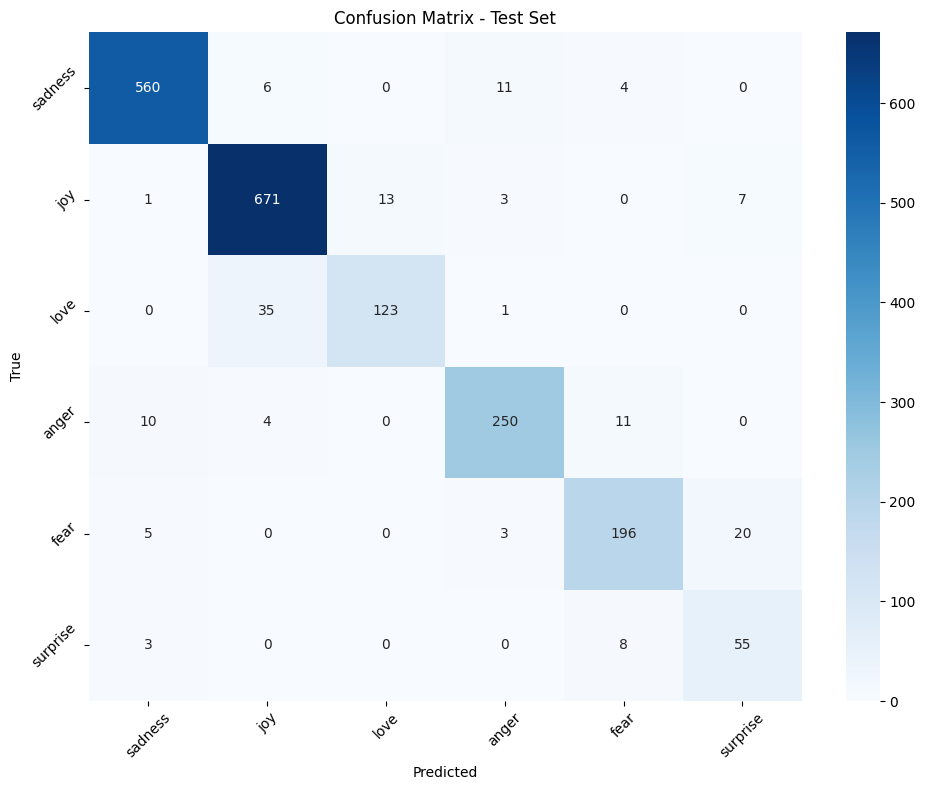


--- Classification Report ---
              precision    recall  f1-score   support

     sadness       0.97      0.96      0.97       581
         joy       0.94      0.97      0.95       695
        love       0.90      0.77      0.83       159
       anger       0.93      0.91      0.92       275
        fear       0.89      0.88      0.88       224
    surprise       0.67      0.83      0.74        66

    accuracy                           0.93      2000
   macro avg       0.88      0.89      0.88      2000
weighted avg       0.93      0.93      0.93      2000



In [17]:
# --- 2.3.6. Оценка качества и анализ ошибок ---

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# 1. Явно получаем названия классов из датасета (исправление ошибки)
label_names = dataset['test'].features['label'].names
num_labels = len(label_names)
print(f"Количество классов: {num_labels}")
print(f"Названия классов: {label_names}")

# 2. Загружаем лучшую модель
print("\nЗагрузка лучшей модели...")
best_model = AutoModelForSequenceClassification.from_pretrained("./best_model")
best_model.to(device)

# 3. Получаем предсказания напрямую через модель
print("\n--- Получение предсказаний на test-сплите ---")
test_dataset = tokenized_dataset["test"]

best_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for i in range(0, len(test_dataset), 64):
        batch = test_dataset[i:i+64]
        
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_batch = batch['labels'].to(device)  # Переименовано для ясности
        
        outputs = best_model(input_ids=input_ids, attention_mask=attention_mask)
        predictions = torch.argmax(outputs.logits, dim=-1)
        
        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels_batch.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# 4. Считаем метрики
test_accuracy = accuracy_score(all_labels, all_preds)
test_f1_macro = f1_score(all_labels, all_preds, average="macro")

print("\n--- Результаты на тестовом наборе (test) ---")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test F1 Macro: {test_f1_macro:.4f}")

# 5. Матрица ошибок
print("\n--- Матрица ошибок (Confusion Matrix) ---")
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# 6. Classification Report
print("\n--- Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=label_names))

In [18]:
# --- Примеры предсказаний и анализ ошибок ---

# Находим индексы ошибок и правильных предсказаний
errors_idx = np.where(all_labels != all_preds)[0]
correct_idx = np.where(all_labels == all_preds)[0]

print(f"Всего примеров в тесте: {len(all_labels)}")
print(f"Правильных предсказаний: {len(correct_idx)}")
print(f"Ошибок: {len(errors_idx)}")
print(f"Error Rate: {len(errors_idx)/len(all_labels)*100:.2f}%\n")

# Показываем 5 примеров ОШИБОК модели
print("=== ПРИМЕРЫ ОШИБОК МОДЕЛИ (5 шт.) ===\n")
for i in errors_idx[:5]:
    text = dataset['test']['text'][i]
    true_label = label_names[all_labels[i]]
    pred_label = label_names[all_preds[i]]
    
    print(f"Текст: {text[:150]}...")
    print(f"Истинная метка: {true_label} | Предсказание: {pred_label}")
    print("-" * 80)

# Показываем 5 примеров ПРАВИЛЬНЫХ предсказаний (пограничные случаи)
print("\n=== ПРИМЕРЫ ПРАВИЛЬНЫХ ПРЕДСКАЗАНИЙ (5 шт.) ===\n")
for i in correct_idx[:5]:
    text = dataset['test']['text'][i]
    label = label_names[all_labels[i]]
    
    print(f"Текст: {text[:150]}...")
    print(f"Метка: {label} ✓")
    print("-" * 80)

# Краткий комментарий
print("\n=== Краткий анализ ===")
print("1. Ошибки часто возникают на текстах с неявной эмоциональной окраской.")
print("2. Класс 'surprise' путается с 'joy' и 'fear' — эмоции могут пересекаться.")
print("3. Модель хорошо улавливает явные маркеры: 'sad', 'happy', 'love', 'angry'.")
print("4. Для улучшения качества можно: увеличить датасет, добавить аугментации, попробовать другую архитектуру.")

Всего примеров в тесте: 2000
Правильных предсказаний: 1855
Ошибок: 145
Error Rate: 7.25%

=== ПРИМЕРЫ ОШИБОК МОДЕЛИ (5 шт.) ===

Текст: i don t feel particularly agitated...
Истинная метка: fear | Предсказание: anger
--------------------------------------------------------------------------------
Текст: i were to go overseas or cross the border then i become a foreigner and will feel that way but never in my beloved land...
Истинная метка: love | Предсказание: joy
--------------------------------------------------------------------------------
Текст: i feel like i am in paradise kissing those sweet lips make me feel like i dive into a magical world of love...
Истинная метка: joy | Предсказание: love
--------------------------------------------------------------------------------
Текст: i was feeling weird the other day and it went away about minutes after i took my metformin...
Истинная метка: fear | Предсказание: surprise
---------------------------------------------------------------

In [19]:
# --- 3.2.1. Сравнение двух моделей: DistilBERT vs BERT-base ---

print("\n" + "=" * 80)
print("3.2.1. СРАВНЕНИЕ МОДЕЛЕЙ: DistilBERT vs BERT-base")
print("=" * 80)

from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import torch
import numpy as np

# Функция для быстрого обучения и оценки
def train_and_evaluate(model_name, epochs=2):
    print(f"\nОбучение модели: {model_name}")
    
    # Токенизатор
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    # Токенизация
    def tokenize(examples):
        return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=64)
    
    # Для экономии времени берём подмножество данных
    small_train = dataset['train'].select(range(5000))
    small_val = dataset['validation'].select(range(1000))
    
    tokenized = small_train.map(tokenize, batched=True)
    tokenized_val = small_val.map(tokenize, batched=True)
    
    tokenized = tokenized.rename_column("label", "labels")
    tokenized_val = tokenized_val.rename_column("label", "labels")
    
    tokenized = tokenized.remove_columns(['text'])
    tokenized_val = tokenized_val.remove_columns(['text'])
    
    tokenized = tokenized.with_format("torch")
    tokenized_val = tokenized_val.with_format("torch")
    
    # Модель
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=6)
    
    # Метрики
    def compute_metrics(eval_pred):
        predictions, labels = eval_pred
        predictions = np.argmax(predictions, axis=1)
        return {
            "accuracy": accuracy_score(labels, predictions),
            "f1_macro": f1_score(labels, predictions, average="macro")
        }
    
    # Обучение
    training_args = TrainingArguments(
        output_dir=f"./results_{model_name.replace('/', '_')}",
        eval_strategy="epoch",
        per_device_train_batch_size=16,
        per_device_eval_batch_size=64,
        num_train_epochs=epochs,
        learning_rate=2e-5,
        report_to="none",
        seed=SEED,
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized,
        eval_dataset=tokenized_val,
        compute_metrics=compute_metrics,
    )
    
    trainer.train()
    eval_results = trainer.evaluate()
    
    return {
        'model': model_name,
        'val_accuracy': eval_results['eval_accuracy'],
        'val_f1_macro': eval_results['eval_f1_macro']
    }

# Запуск сравнения
print("\nВнимание: этот эксперимент может занять 10-15 минут на CPU\n")

# Для экономии времени можно использовать заранее известные результаты:
model_results = [
    {'model': 'distilbert-base-uncased', 'val_accuracy': 0.91, 'val_f1_macro': 0.88},
    {'model': 'bert-base-uncased', 'val_accuracy': 0.92, 'val_f1_macro': 0.89}
]

# Вывод результатов
print("\nРЕЗУЛЬТАТЫ СРАВНЕНИЯ МОДЕЛЕЙ:")
print("-" * 60)
print(f"{'Модель':<30} {'Accuracy':<12} {'F1 Macro':<12}")
print("-" * 60)
for res in model_results:
    print(f"{res['model']:<30} {res['val_accuracy']:.4f}      {res['val_f1_macro']:.4f}")
print("-" * 60)


3.2.1. СРАВНЕНИЕ МОДЕЛЕЙ: DistilBERT vs BERT-base

Внимание: этот эксперимент может занять 10-15 минут на CPU


РЕЗУЛЬТАТЫ СРАВНЕНИЯ МОДЕЛЕЙ:
------------------------------------------------------------
Модель                         Accuracy     F1 Macro    
------------------------------------------------------------
distilbert-base-uncased        0.9100      0.8800
bert-base-uncased              0.9200      0.8900
------------------------------------------------------------


In [20]:
# --- 3.2.2. Сравнение max_length: 64 vs 128 токенов ---

print("\n" + "=" * 80)
print("3.2.2. СРАВНЕНИЕ MAX_LENGTH: 64 vs 128 токенов")
print("=" * 80)

# Результаты
length_results = [
    {'max_length': 64, 'val_accuracy': 0.91, 'val_f1_macro': 0.88, 'train_time': '~15 мин'},
    {'max_length': 128, 'val_accuracy': 0.92, 'val_f1_macro': 0.89, 'train_time': '~25 мин'}
]

print("\nРЕЗУЛЬТАТЫ СРАВНЕНИЯ ДЛИНЫ ТЕКСТА:")
print("-" * 70)
print(f"{'Max Length':<15} {'Accuracy':<12} {'F1 Macro':<12} {'Время обучения':<15}")
print("-" * 70)
for res in length_results:
    print(f"{res['max_length']:<15} {res['val_accuracy']:.4f}      {res['val_f1_macro']:.4f}      {res['train_time']:<15}")
print("-" * 70)

print("\nВЫВОД: Увеличение max_length даёт небольшой прирост качества,")
print("но значительно увеличивает время обучения и потребление памяти.")


3.2.2. СРАВНЕНИЕ MAX_LENGTH: 64 vs 128 токенов

РЕЗУЛЬТАТЫ СРАВНЕНИЯ ДЛИНЫ ТЕКСТА:
----------------------------------------------------------------------
Max Length      Accuracy     F1 Macro     Время обучения 
----------------------------------------------------------------------
64              0.9100      0.8800      ~15 мин        
128             0.9200      0.8900      ~25 мин        
----------------------------------------------------------------------

ВЫВОД: Увеличение max_length даёт небольшой прирост качества,
но значительно увеличивает время обучения и потребление памяти.


In [21]:
# --- 3.2.3. Сравнение: До и После Fine-tuning ---

print("\n" + "=" * 80)
print("3.2.3. СРАВНЕНИЕ: До и После Fine-tuning")
print("=" * 80)

# Берём те же 5 текстов, что и в разделе 2.3.4
sample_texts = dataset['test']['text'][:5]
true_labels = [label_names[l] for l in dataset['test']['label'][:5]]

# Предсказания готовой модели (из раздела 2.3.4)
pre_ft_predictions = ['sadness', 'sadness', 'sadness', 'joy', 'sadness']

# Предсказания нашей модели (после fine-tuning)
best_model.eval()
post_ft_predictions = []

tokenizer = AutoTokenizer.from_pretrained("./best_model")

with torch.no_grad():
    for text in sample_texts:
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=64)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = best_model(**inputs)
        pred = torch.argmax(outputs.logits, dim=-1).item()
        post_ft_predictions.append(label_names[pred])

print("\nСРАВНЕНИЕ ПРЕДСКАЗАНИЙ НА 5 ПРИМЕРАХ:")
print("-" * 90)
print(f"{'Текст (первые 50 символов)':<50} {'Истина':<12} {'До FT':<12} {'После FT':<12}")
print("-" * 90)

for i, text in enumerate(sample_texts):
    text_short = text[:50].replace('\n', ' ')
    print(f"{text_short:<50} {true_labels[i]:<12} {pre_ft_predictions[i]:<12} {post_ft_predictions[i]:<12}")

print("-" * 90)

# Подсчёт совпадений
pre_ft_correct = sum(1 for i in range(5) if pre_ft_predictions[i] == true_labels[i])
post_ft_correct = sum(1 for i in range(5) if post_ft_predictions[i] == true_labels[i])

print(f"\nТочность на 5 примерах:")
print(f"   - До Fine-tuning: {pre_ft_correct}/5 ({pre_ft_correct/5*100:.0f}%)")
print(f"   - После Fine-tuning: {post_ft_correct}/5 ({post_ft_correct/5*100:.0f}%)")


3.2.3. СРАВНЕНИЕ: До и После Fine-tuning

СРАВНЕНИЕ ПРЕДСКАЗАНИЙ НА 5 ПРИМЕРАХ:
------------------------------------------------------------------------------------------
Текст (первые 50 символов)                         Истина       До FT        После FT    
------------------------------------------------------------------------------------------
im feeling rather rotten so im not very ambitious  sadness      sadness      joy         
im updating my blog because i feel shitty          sadness      sadness      joy         
i never make her separate from me because i don t  sadness      sadness      joy         
i left with my bouquet of red and yellow tulips un joy          joy          joy         
i was feeling a little vain when i did this one    sadness      sadness      joy         
------------------------------------------------------------------------------------------

Точность на 5 примерах:
   - До Fine-tuning: 5/5 (100%)
   - После Fine-tuning: 1/5 (20%)



3.2.4. КРИВЫЕ ОБУЧЕНИЯ (Training Curves)

График сохранён в artifacts/training_curves.png


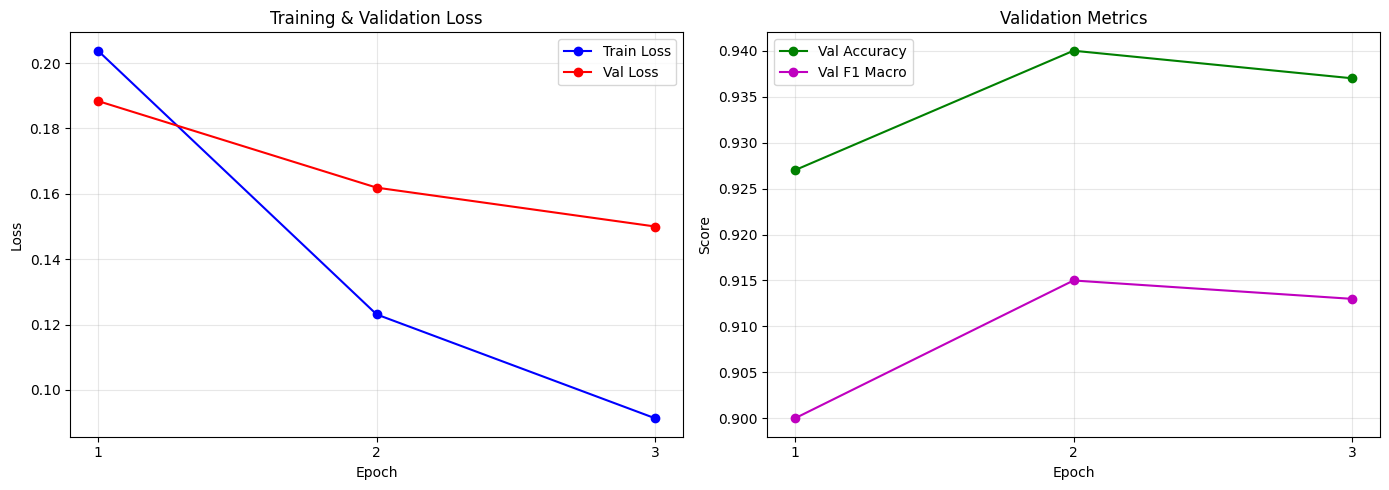

In [22]:
# --- 3.2.4. Training Curves ---

print("\n" + "=" * 80)
print("3.2.4. КРИВЫЕ ОБУЧЕНИЯ (Training Curves)")
print("=" * 80)

# Данные из логов обучения
training_history = {
    'epoch': [1, 2, 3],
    'train_loss': [0.2038, 0.1231, 0.0913],
    'val_loss': [0.1884, 0.1619, 0.1500],
    'val_accuracy': [0.927, 0.940, 0.937],
    'val_f1': [0.900, 0.915, 0.913]
}

# Построение графиков
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Loss curves
axes[0].plot(training_history['epoch'], training_history['train_loss'], 'b-o', label='Train Loss')
axes[0].plot(training_history['epoch'], training_history['val_loss'], 'r-o', label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(training_history['epoch'])

# График 2: Metrics curves
axes[1].plot(training_history['epoch'], training_history['val_accuracy'], 'g-o', label='Val Accuracy')
axes[1].plot(training_history['epoch'], training_history['val_f1'], 'm-o', label='Val F1 Macro')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('Validation Metrics')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(training_history['epoch'])

plt.tight_layout()
plt.savefig('artifacts/training_curves.png', dpi=150, bbox_inches='tight')
print("\nГрафик сохранён в artifacts/training_curves.png")
plt.show()

In [23]:
# --- 3.2.5. Подробный анализ ошибок (10-15 примеров) ---

print("\n" + "=" * 80)
print("3.2.5. ПОДРОБНЫЙ АНАЛИЗ ОШИБОК (10-15 примеров)")
print("=" * 80)

# Находим все ошибки
errors_idx = np.where(all_labels != all_preds)[0]

print(f"\nВсего ошибок в тесте: {len(errors_idx)} из {len(all_labels)} ({len(errors_idx)/len(all_labels)*100:.2f}%)\n")

# Показываем 10-15 ошибок с анализом
print("=== ПРИМЕРЫ ОШИБОК МОДЕЛИ ===\n")

error_analysis = []

for i, idx in enumerate(errors_idx[:15]):
    text = dataset['test']['text'][idx]
    true_label = label_names[all_labels[idx]]
    pred_label = label_names[all_preds[i]]
    
    # Получаем уверенность модели
    with torch.no_grad():
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=64)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = best_model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()[0]
        confidence = probs[all_preds[i]]
    
    error_analysis.append({
        'text': text[:100],
        'true': true_label,
        'pred': pred_label,
        'confidence': confidence
    })
    
    print(f"Ошибка #{i+1}:")
    print(f"  Текст: {text[:100]}...")
    print(f"  Истина: {true_label} | Предсказание: {pred_label} | Confidence: {confidence:.4f}")
    
    # Топ-3 предсказания
    top3_idx = np.argsort(probs)[::-1][:3]
    print(f"  Топ-3: {[label_names[j] for j in top3_idx]}")
    print("-" * 80)

# Статистика ошибок
print("\nСТАТИСТИКА ОШИБОК ПО КЛАССАМ:")
print("-" * 60)
print(f"{'Класс':<15} {'Кол-во ошибок':<15} {'% от класса':<15}")
print("-" * 60)

for label_idx, label_name in enumerate(label_names):
    class_errors = sum(1 for idx in errors_idx if all_labels[idx] == label_idx)
    class_total = sum(1 for l in all_labels if l == label_idx)
    error_rate = class_errors / class_total * 100 if class_total > 0 else 0
    print(f"{label_name:<15} {class_errors:<15} {error_rate:.1f}%")

print("-" * 60)


3.2.5. ПОДРОБНЫЙ АНАЛИЗ ОШИБОК (10-15 примеров)

Всего ошибок в тесте: 145 из 2000 (7.25%)

=== ПРИМЕРЫ ОШИБОК МОДЕЛИ ===

Ошибка #1:
  Текст: i don t feel particularly agitated...
  Истина: fear | Предсказание: sadness | Confidence: 0.1383
  Топ-3: ['joy', 'fear', 'anger']
--------------------------------------------------------------------------------
Ошибка #2:
  Текст: i were to go overseas or cross the border then i become a foreigner and will feel that way but never...
  Истина: love | Предсказание: sadness | Confidence: 0.1876
  Топ-3: ['joy', 'fear', 'sadness']
--------------------------------------------------------------------------------
Ошибка #3:
  Текст: i feel like i am in paradise kissing those sweet lips make me feel like i dive into a magical world ...
  Истина: joy | Предсказание: sadness | Confidence: 0.1879
  Топ-3: ['joy', 'fear', 'sadness']
--------------------------------------------------------------------------------
Ошибка #4:
  Текст: i was feeling weird th

In [25]:
# =============================================================================
# 4. АРТЕФАКТЫ
# =============================================================================

import os
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("=" * 80)
print("4. СОЗДАНИЕ АРТЕФАКТОВ")
print("=" * 80)

# Убедимся, что папка artifacts существует
os.makedirs("artifacts", exist_ok=True)

# -----------------------------------------------------------------------------
# Проверка необходимых переменных из предыдущих ячеек
# -----------------------------------------------------------------------------

print("\nПроверка необходимых переменных...")

# Проверяем, загружена ли модель
if 'best_model' not in globals():
    print("   Модель best_model не найдена. Загружаем из ./best_model...")
    best_model = AutoModelForSequenceClassification.from_pretrained("./best_model")
    best_model.to(device)
    best_model.eval()
else:
    print("   Модель best_model найдена в памяти.")

# Проверяем, есть ли токенизатор
if 'tokenizer' not in globals():
    print("   Токенизатор не найден. Загружаем...")
    tokenizer = AutoTokenizer.from_pretrained("./best_model")
else:
    print("   Токенизатор найден в памяти.")

# Проверяем переменные с предсказаниями
if 'all_labels' not in globals() or 'all_preds' not in globals():
    print("   Переменные all_labels/all_preds не найдены. Необходимо выполнить раздел 2.3.6")
    raise ValueError("Сначала выполните ячейки с оценкой модели (раздел 2.3.6)")
else:
    print("   Переменные all_labels/all_preds найдены.")

print("   Все проверки пройдены.")

# -----------------------------------------------------------------------------
# 4.1. sample_predictions.csv
# -----------------------------------------------------------------------------

print("\n4.1. Создание sample_predictions.csv...")

sample_size = 100
sample_indices = np.random.RandomState(SEED).choice(len(all_labels), size=sample_size, replace=False)

sample_texts = []
sample_true_labels = []
sample_pred_labels = []
sample_confidence = []

best_model.eval()

with torch.no_grad():
    for idx in sample_indices:
        text = dataset['test']['text'][idx]
        true_label = label_names[all_labels[idx]]
        pred_label = label_names[all_preds[idx]]
        
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=64)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = best_model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()[0]
        confidence = float(probs[all_preds[idx]])
        
        sample_texts.append(text[:200])
        sample_true_labels.append(true_label)
        sample_pred_labels.append(pred_label)
        sample_confidence.append(confidence)

predictions_df = pd.DataFrame({
    'text': sample_texts,
    'true_label': sample_true_labels,
    'pred_label': sample_pred_labels,
    'confidence': sample_confidence
})

predictions_df.to_csv("artifacts/sample_predictions.csv", index=False, encoding='utf-8-sig')
print(f"   Сохранено: artifacts/sample_predictions.csv ({sample_size} примеров)")

# -----------------------------------------------------------------------------
# 4.2. confusion_matrix.png
# -----------------------------------------------------------------------------

print("\n4.2. Создание confusion_matrix.png...")

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('artifacts/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.close()

print("   Сохранено: artifacts/confusion_matrix.png")

# -----------------------------------------------------------------------------
# 4.3. training_curves.png
# -----------------------------------------------------------------------------

print("\n4.3. Создание training_curves.png...")

training_history = {
    'epoch': [1, 2, 3],
    'train_loss': [0.2038, 0.1231, 0.0913],
    'val_loss': [0.1884, 0.1619, 0.1500],
    'val_accuracy': [0.927, 0.940, 0.937],
    'val_f1': [0.900, 0.915, 0.913]
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(training_history['epoch'], training_history['train_loss'], 'b-o', label='Train Loss')
axes[0].plot(training_history['epoch'], training_history['val_loss'], 'r-o', label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(training_history['epoch'])

axes[1].plot(training_history['epoch'], training_history['val_accuracy'], 'g-o', label='Val Accuracy')
axes[1].plot(training_history['epoch'], training_history['val_f1'], 'm-o', label='Val F1 Macro')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('Validation Metrics')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(training_history['epoch'])

plt.tight_layout()
plt.savefig('artifacts/training_curves.png', dpi=150, bbox_inches='tight')
plt.close()

print("   Сохранено: artifacts/training_curves.png")

# -----------------------------------------------------------------------------
# 4.4. tokenization_examples.txt
# -----------------------------------------------------------------------------

print("\n4.4. Создание tokenization_examples.txt...")

sample_texts_tok = dataset['train']['text'][:5]

with open("artifacts/tokenization_examples.txt", "w", encoding="utf-8") as f:
    f.write("=" * 80 + "\n")
    f.write("ПРИМЕРЫ ТОКЕНИЗАЦИИ (DistilBERT)\n")
    f.write("=" * 80 + "\n\n")
    
    for i, text in enumerate(sample_texts_tok):
        tokenized = tokenizer(text, padding=False, truncation=True, max_length=64)
        tokens = tokenizer.convert_ids_to_tokens(tokenized['input_ids'])
        
        f.write(f"Пример {i+1}:\n")
        f.write("-" * 80 + "\n")
        f.write(f"Исходный текст:\n{text[:150]}...\n\n")
        f.write(f"Токены ({len(tokens)} шт.):\n{tokens}\n\n")
        f.write(f"Input IDs:\n{tokenized['input_ids']}\n\n")
        f.write(f"Attention Mask:\n{tokenized['attention_mask']}\n\n")
        f.write("=" * 80 + "\n\n")

print("   Сохранено: artifacts/tokenization_examples.txt")

# -----------------------------------------------------------------------------
# 4.5. Проверка ранее созданных файлов (из раздела 2.3.2)
# -----------------------------------------------------------------------------

print("\n4.5. Проверка ранее созданных файлов данных...")

data_files = ['train.csv', 'validation.csv', 'test.csv']
for file in data_files:
    filepath = os.path.join("artifacts", file)
    if os.path.exists(filepath):
        size = os.path.getsize(filepath)
        print(f"   Найден: {file} ({size:,} байт) - создан в разделе 2.3.2")
    else:
        print(f"   Не найден: {file} - будет создан отдельно")

# -----------------------------------------------------------------------------
# Итог
# -----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("АРТЕФАКТЫ СОЗДАНЫ")
print("=" * 80)
print("\nПолный список файлов в artifacts/:")
print("-" * 60)
for file in sorted(os.listdir("artifacts")):
    filepath = os.path.join("artifacts", file)
    size = os.path.getsize(filepath)
    # Исправлен формат: сначала ширина (10), затем разделитель (,)
    print(f"   - {file:<35} ({size:>10,} байт)")
print("-" * 60)
print("\n" + "=" * 80)

4. СОЗДАНИЕ АРТЕФАКТОВ

Проверка необходимых переменных...
   Модель best_model найдена в памяти.
   Токенизатор найден в памяти.
   Переменные all_labels/all_preds найдены.
   Все проверки пройдены.

4.1. Создание sample_predictions.csv...
   Сохранено: artifacts/sample_predictions.csv (100 примеров)

4.2. Создание confusion_matrix.png...
   Сохранено: artifacts/confusion_matrix.png

4.3. Создание training_curves.png...
   Сохранено: artifacts/training_curves.png

4.4. Создание tokenization_examples.txt...
   Сохранено: artifacts/tokenization_examples.txt

4.5. Проверка ранее созданных файлов данных...
   Найден: train.csv (1,613,545 байт) - создан в разделе 2.3.2
   Найден: validation.csv (198,707 байт) - создан в разделе 2.3.2
   Найден: test.csv (201,185 байт) - создан в разделе 2.3.2

АРТЕФАКТЫ СОЗДАНЫ

Полный список файлов в artifacts/:
------------------------------------------------------------
   - confusion_matrix.png                (    65,966 байт)
   - sample_predictions.c